# **3. Análisis Exploratorio**

## **librerias**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

## **1. Carga de la Base de Datos**

In [2]:
df_original= pd.read_csv('dataset.csv')
df= df_original.copy()

## **2. Vista inicial del Dataset**

In [3]:
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


## **3. Limpieza de Nombres**

In [4]:
df.columns = ['estado' , 'sexo' , 'salud_general' , 'dias_salud_fisica' , 'dias_salud_mental' , 'ultimo_chequeo' , 'actividades_fisicas' , 'horas_sueño' , 'dientes_removidos' , 'ataque_cardiaco' , 'angina' , 'ACV' , 'asma' , 'cancer_piel' , 'EPOC' , 'trastorno_depre' , 'enfermedad_riñon' , 'artritis' , 'diabetes' , 'sordo_semisordo' , 'ciego_semiciego' , 'dif_concentracion' , 'dif_caminar' , 'dif_vestirduchar' , 'dif_encargo' ,'estado_fumador' , 'uso_cigarroelect' , 'escaner_torax' , 'categoria_etnica' , 'categoria_edad' , 'altura_metros' , 'peso_kilos' , 'bmi' , 'bebedor_alcohol' , 'prueba_VIH' , 'gripa_vac' , 'pneumo' , 'tetanos' , 'alto_riesgo_ap' , 'covid']
df.columns

Index(['estado', 'sexo', 'salud_general', 'dias_salud_fisica',
       'dias_salud_mental', 'ultimo_chequeo', 'actividades_fisicas',
       'horas_sueño', 'dientes_removidos', 'ataque_cardiaco', 'angina', 'ACV',
       'asma', 'cancer_piel', 'EPOC', 'trastorno_depre', 'enfermedad_riñon',
       'artritis', 'diabetes', 'sordo_semisordo', 'ciego_semiciego',
       'dif_concentracion', 'dif_caminar', 'dif_vestirduchar', 'dif_encargo',
       'estado_fumador', 'uso_cigarroelect', 'escaner_torax',
       'categoria_etnica', 'categoria_edad', 'altura_metros', 'peso_kilos',
       'bmi', 'bebedor_alcohol', 'prueba_VIH', 'gripa_vac', 'pneumo',
       'tetanos', 'alto_riesgo_ap', 'covid'],
      dtype='object')

Se han reemplazado los nombres de las columnas por su traduccion al español.

## **4. Descripción Estadística**

In [5]:
df.describe().T.style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
dias_salud_fisica,246022.000000,4.119026,8.405844,0.000000,0.000000,0.000000,3.000000,30.000000
dias_salud_mental,246022.000000,4.167140,8.102687,0.000000,0.000000,0.000000,4.000000,30.000000
horas_sueño,246022.000000,7.021331,1.440681,1.000000,6.000000,7.000000,8.000000,24.000000
altura_metros,246022.000000,1.705150,0.106654,0.910000,1.630000,1.700000,1.780000,2.410000
peso_kilos,246022.000000,83.615179,21.323156,28.120000,68.040000,81.650000,95.250000,292.570000
bmi,246022.000000,28.668136,6.513973,12.020000,24.270000,27.460000,31.890000,97.650000


Este resumen estadístico incluye medidas clave para seis variables cuantitativas del conjunto de datos, el cual contiene **246,022 registros**:

- **`dias_salud_fisica` y `dias_salud_mental`**  
  Representan la cantidad de días en el último mes que la persona reportó mala salud física o mental, respectivamente.  
  - Promedio de aproximadamente **4 días**, pero con una **mediana de 0**, lo que indica que más del 50% de los encuestados no reportó problemas de salud en ese periodo.  
  - Valor máximo de **30 días**, indicando presencia de personas con malestar continuo durante todo el mes.

- **`horas_sueño`**  
  Número de horas de sueño que reporta la persona por noche.  
  - Promedio de **7 horas**, considerado dentro del rango saludable.  
  - Rango desde **1 hasta 24 horas**, lo que sugiere posibles valores atípicos o errores de reporte.

- **`altura_metros` y `peso_kilos`**  
  Medidas antropométricas del individuo.  
  - Altura media: **1.70 metros**  
  - Peso medio: **83.6 kg**  
  - Se observan valores extremos: altura máxima de **2.41 m** y peso máximo de **292.57 kg**, lo que podría requerir revisión o limpieza.

- **`bmi` (índice de masa corporal)**  
  Calculado con base en el peso y la altura.  
  - Promedio de **28.7**, clasificado como **sobrepeso** según la OMS.  
  - Rango de **12.0 a 97.65**, que incluye tanto casos de bajo peso como de obesidad extrema, posibles outliers o errores.

## **5. Tratamiento de Duplicados**

In [6]:
print("\nNúmero de filas duplicadas:")
print(df.duplicated().sum())


Número de filas duplicadas:
9


In [7]:
df[df.duplicated()]

,estado,sexo,salud_general,dias_salud_fisica,dias_salud_mental,ultimo_chequeo,actividades_fisicas,horas_sueño,dientes_removidos,ataque_cardiaco,...,altura_metros,peso_kilos,bmi,bebedor_alcohol,prueba_VIH,gripa_vac,pneumo,tetanos,alto_riesgo_ap,covid
5702,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.70,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
87555,Maryland,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,1.65,45.36,16.64,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
88402,Maryland,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,1.75,65.77,21.41,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
137645,New Jersey,Male,Good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.63,80.74,30.55,Yes,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
174923,Rhode Island,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,1 to 5,No,...,1.57,68.04,27.44,Yes,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
184137,South Dakota,Female,Fair,30.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.75,90.72,29.53,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
208013,Vermont,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.65,79.38,29.12,Yes,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
216362,Washington,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.80,77.11,23.71,Yes,Yes,Yes,No,"Yes, received Tdap",No,No
225974,Washington,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.93,104.33,28.00,Yes,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [8]:
df= df.drop_duplicates() #limpiamos los duplicados

In [9]:
# Comprobamos limpieza
print(df.duplicated().sum())

0


## **6. Análisis de variable numéricas**

### **Variables numéricas (6)**
- **`dias_salud_fisica`**: Número de días en el último mes con mala salud física.  
- **`dias_salud_mental`**: Número de días en el último mes con mala salud mental.  
- **`horas_sueño`**: Horas promedio de sueño por noche.  
- **`altura_metros`**: Altura en metros.  
- **`peso_kilos`**: Peso en kilogramos.  
- **`bmi`**: Índice de Masa Corporal (IMC).  


In [10]:
num_cols = df.select_dtypes(include="float").columns

### **Histogramas**

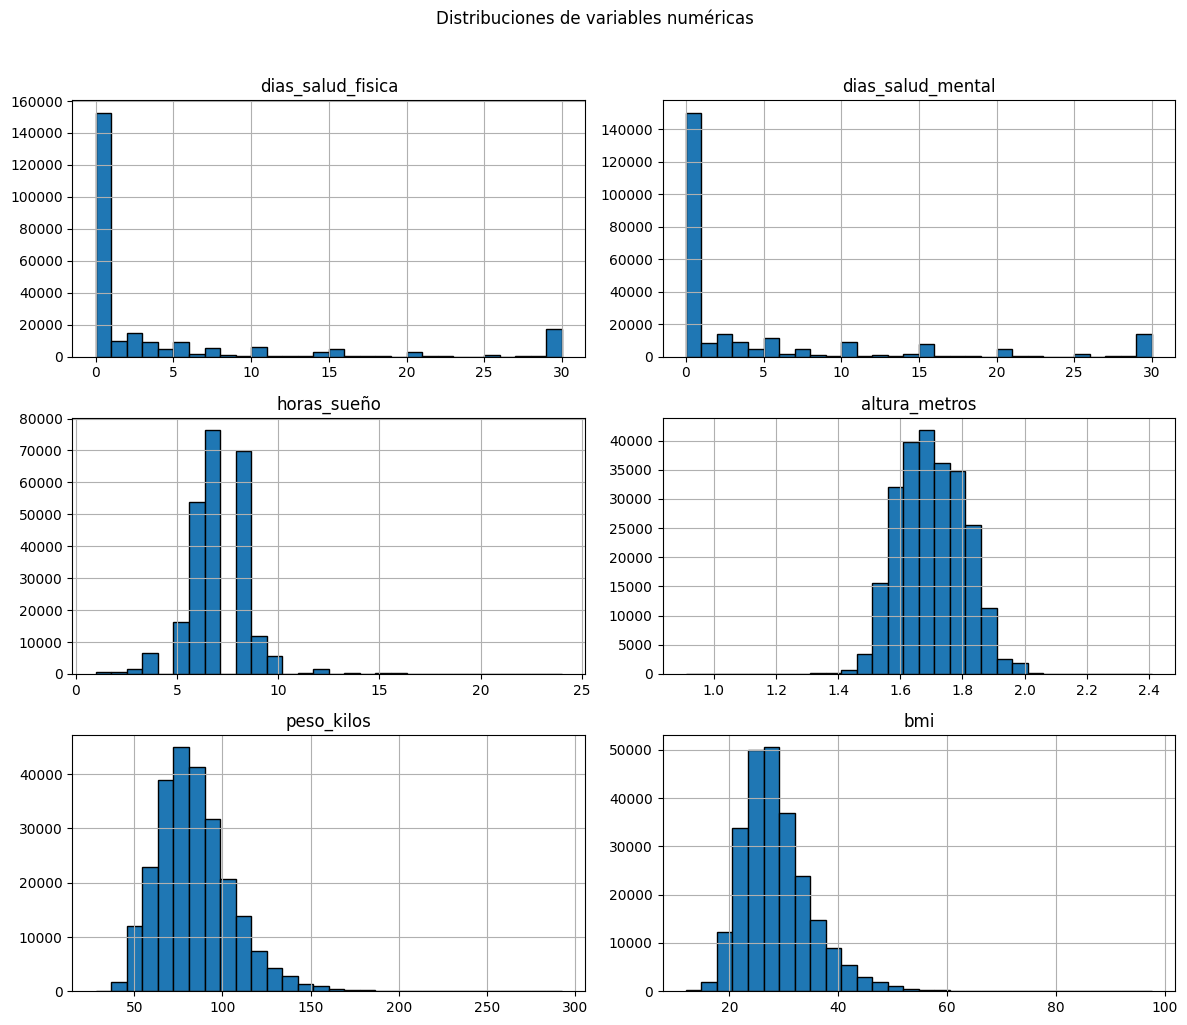

In [11]:
# Histograma para distribución de variables numéricas
df[num_cols].hist(bins=30, figsize=(12, 10), edgecolor='black')
plt.suptitle("Distribuciones de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

 Se presentan las distribuciones de seis variables numéricas clave del conjunto de datos, que permiten observar la forma de los datos y la presencia de posibles valores atípicos:

- **`dias_salud_fisica` y `dias_salud_mental`**  
  Ambas variables muestran una distribución fuertemente **asimétrica a la derecha (sesgada positiva)**, con un alto número de personas que reportan **0 días de mala salud** en el último mes. También se observa un pequeño pico en el valor **30**, lo que podría representar personas con malestar persistente o respuestas extremas.

- **`horas_sueño`**  
  La distribución tiene una forma **aproximadamente normal**, centrada entre **6 y 8 horas** por noche. Existen pocos casos extremos con menos de 4 o más de 12 horas, lo cual podría indicar hábitos poco comunes o errores.

- **`altura_metros`**  
  Presenta una **distribución simétrica y normal**, centrada alrededor de **1.7 metros**, lo esperado en una población general.

- **`peso_kilos`**  
  Exhibe una distribución **asimétrica a la derecha**, indicando que la mayoría de las personas pesan entre **60 y 100 kg**, pero existen casos con pesos significativamente mayores, que podrían ser atípicos.

- **`bmi` (índice de masa corporal)**  
  También muestra una **asimetría a la derecha**, con una concentración de individuos en rangos de sobrepeso (**25-30**) y obesidad (**>30**). Hay valores superiores a **60**, que podrían ser casos extremos o errores de digitación.


### **Análisis de Outliers**

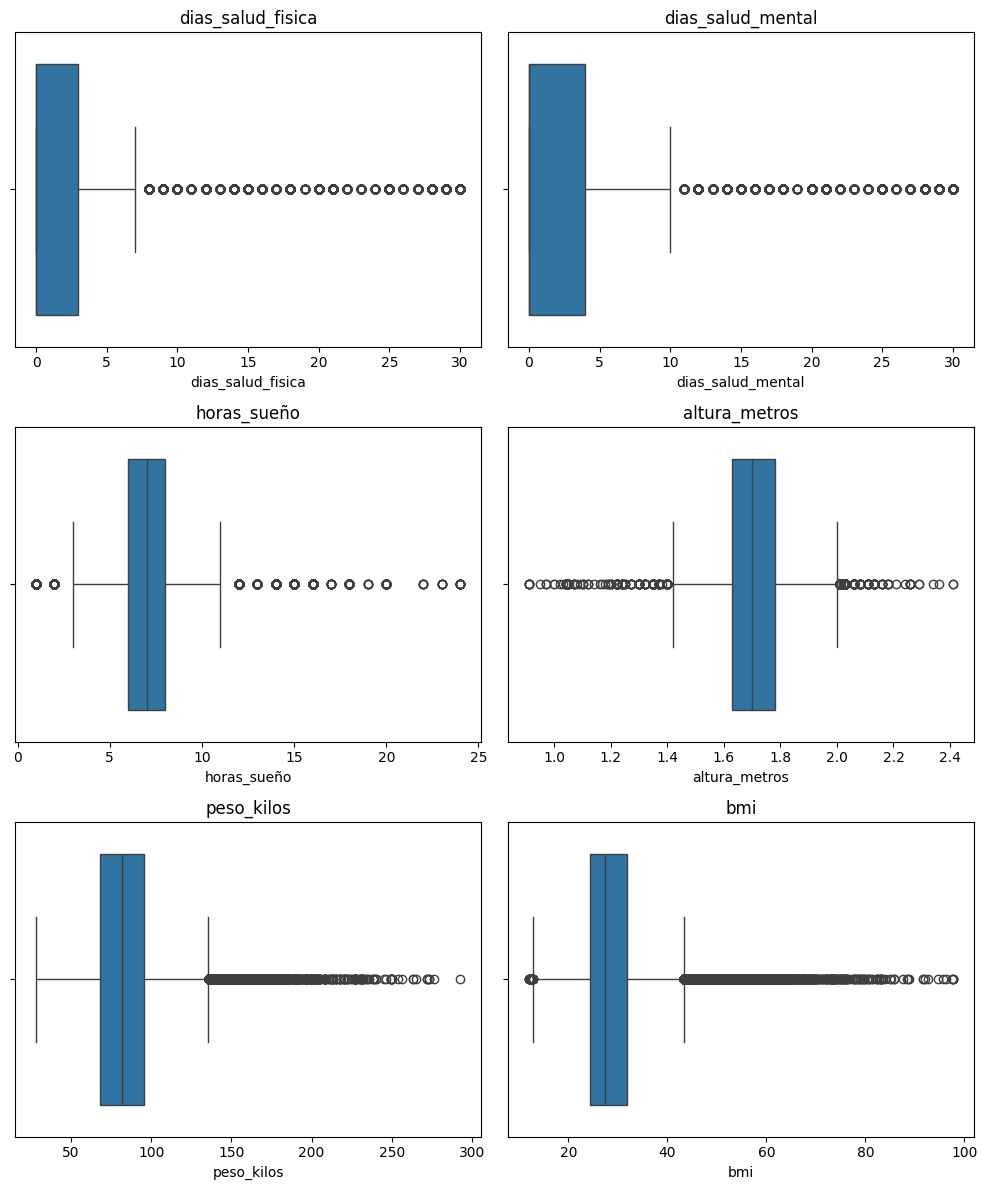

In [12]:
plots_per_row = 2
n = len(num_cols)
rows = math.ceil(n/plots_per_row)
fig, axes = plt.subplots(rows, plots_per_row, figsize=(5*plots_per_row,4*rows))
for i, col in enumerate(num_cols):
  ax = axes.flatten()[i]
  sns.boxplot(x=df[col], ax=ax).set_title(col)
for ax in axes.flatten()[n:]: fig.delaxes(ax)
plt.tight_layout()

Los diagramas de caja permiten visualizar la dispersión de los datos y la presencia de **valores atípicos** (outliers) en cada variable. A continuación, se describe lo observado en cada caso:

- **`dias_salud_fisica` y `dias_salud_mental`**  
  - La mayoría de los valores están concentrados entre 0 y 5 días.
  - Existen numerosos **valores atípicos hacia la derecha**, especialmente en **30 días**, lo que puede representar respuestas extremas (posiblemente personas con malestar todo el mes).

- **`horas_sueño`**  
  - La mediana se encuentra cerca de las 7 horas.
  - Hay outliers tanto en valores bajos (< 4 h) como altos (> 12 h), lo cual podría reflejar hábitos extremos o errores en la respuesta.

- **`altura_metros`**  
  - Tiene una distribución más simétrica.
  - Se identifican valores atípicos por debajo de 1.3 m y por encima de 2.1 m, lo cual puede ser real o deberse a errores de captura.

- **`peso_kilos`**  
  - Se identifican muchos **outliers por exceso**, especialmente en pesos mayores a 150 kg.
  - Aunque hay una tendencia normal, la dispersión sugiere una posible revisión o tratamiento de valores extremos.

- **`bmi` (índice de masa corporal)**  
  - Muestra una concentración de datos en rangos de sobrepeso y obesidad.
  - Presenta numerosos valores atípicos hacia la derecha, superando incluso los **60 puntos de IMC**, lo cual podría representar condiciones médicas graves o errores de digitación.


## **7. Análisis de Variables Categóricas**

### **Variables Categóticas (34)**
- **`estado`**: Estado de residencia (en EE. UU. o región de referencia).  
- **`sexo`**: Sexo del encuestado.  
- **`salud_general`**: Autopercepción del estado de salud general.  
- **`ultimo_chequeo`**: Tiempo desde la última revisión médica.  
- **`actividades_fisicas`**: Realiza actividad física regularmente (Sí/No).  
- **`dientes_removidos`**: Número de dientes extraídos.  

**Antecedentes de salud (Sí/No)**
- **`ataque_cardiaco`**: Ha tenido un ataque cardíaco.  
- **`angina`**: Ha sufrido angina de pecho.  
- **`ACV`**: Ha sufrido accidente cerebrovascular.  
- **`asma`**: Ha sido diagnosticado con asma.  
- **`cancer_piel`**: Ha tenido cáncer de piel.  
- **`EPOC`**: Ha sido diagnosticado con enfermedad pulmonar obstructiva crónica (EPOC).  
- **`trastorno_depre`**: Ha sido diagnosticado con depresión.  
- **`enfermedad_riñon`**: Tiene enfermedad renal crónica.  
- **`artritis`**: Ha sido diagnosticado con artritis.  
- **`diabetes`**: Ha sido diagnosticado con diabetes.  

**Discapacidades sensoriales**
- **`sordo_semisordo`**: Presenta sordera o dificultad auditiva.  
- **`ciego_semiciego`**: Presenta ceguera o dificultad visual.  

**Dificultades funcionales**
- **`dif_concentracion`**: Dificultad para concentrarse o recordar.  
- **`dif_caminar`**: Dificultad para caminar o subir escaleras.  
- **`dif_vestirduchar`**: Dificultad para vestirse o bañarse.  
- **`dif_encargo`**: Dificultad para realizar encargos o actividades cotidianas solo.  

**Hábitos y conductas**
- **`estado_fumador`**: Estado de fumador (Nunca, Exfumador, Actual).  
- **`uso_cigarroelect`**: Uso de cigarrillos electrónicos (Sí/No).  
- **`bebedor_alcohol`**: Consumo de alcohol en el último mes (Sí/No).  

**Prevención y chequeos médicos**
- **`escaner_torax`**: Realización de escáner de tórax (Sí/No).  
- **`prueba_VIH`**: Se ha realizado prueba de VIH alguna vez (Sí/No).  
- **`gripa_vac`**: Vacunación contra la gripe en los últimos 12 meses (Sí/No).  
- **`pneumo`**: Vacunación antineumocócica alguna vez (Sí/No).  
- **`tetanos`**: Vacunación de tétanos (Tdap) en los últimos 10 años (Sí/No).  

**Sociodemográficas**
- **`categoria_etnica`**: Categoría de raza o etnia.  
- **`categoria_edad`**: Categoría de edad.  

**Covid-19**
- **`alto_riesgo_ap`**: Exposición a entornos de alto riesgo de COVID-19 en el último año (Sí/No).  
- **`covid`**: Resultado positivo de COVID-19 en el último año (Sí/No).  

In [13]:
cat_cols = df.select_dtypes(include="object").columns

### **Conteo de Clases**

In [14]:
for col in cat_cols:
    print(f"\n Columna: {col}")
    print(df[col].value_counts(dropna=False))


 Columna: estado
estado
Washington              14998
Maryland                 9163
Minnesota                9161
Ohio                     8995
New York                 8923
Texas                    7408
Florida                  7315
Kansas                   6145
Wisconsin                6126
Maine                    6013
Iowa                     5672
Hawaii                   5596
Virginia                 5565
Indiana                  5502
South Carolina           5471
Massachusetts            5465
Arizona                  5461
Utah                     5373
Michigan                 5370
Colorado                 5159
Nebraska                 5107
California               5096
Connecticut              5053
Georgia                  4978
Vermont                  4844
South Dakota             4404
Montana                  4264
Missouri                 4195
New Jersey               3966
New Hampshire            3756
Puerto Rico              3589
Idaho                    3468
Alaska         

## **8. Limpieza de Clases**

In [15]:
# Reemplazar las clases por 'No'
df["diabetes"] = df["diabetes"].replace({
    "Yes, but only during pregnancy (female)": "No",
    "No, pre-diabetes or borderline diabetes": "No"
})
df['diabetes'].value_counts()

diabetes
No     212202
Yes     33811
Name: count, dtype: int64

In [16]:
df['sexo'].value_counts(normalize=True)

sexo
Female    0.519509
Male      0.480491
Name: proportion, dtype: float64

In [17]:
df['estado_fumador'].value_counts(normalize=True)

estado_fumador
Never smoked                             0.600501
Former smoker                            0.278538
Current smoker - now smokes every day    0.088040
Current smoker - now smokes some days    0.032921
Name: proportion, dtype: float64

In [18]:
df["estado_fumador"] = df["estado_fumador"].replace({
    "Current smoker - now smokes every day": "Current smoker",
    "Current smoker - now smokes some days": "Current smoker"
})
df['estado_fumador'].value_counts()

estado_fumador
Never smoked      147731
Former smoker      68524
Current smoker     29758
Name: count, dtype: int64

In [19]:
df['uso_cigarroelect'].value_counts(normalize=True)

uso_cigarroelect
Never used e-cigarettes in my entire life    0.772801
Not at all (right now)                       0.175930
Use them some days                           0.027064
Use them every day                           0.024206
Name: proportion, dtype: float64

In [20]:
df["uso_cigarroelect"] = df["uso_cigarroelect"].replace({
    "Never used e-cigarettes in my entire life": "Never",
    "Not at all (right now)": "Stop",
    "Use them some days": "Current",
    "Use them every day": "Smoker"
})
df['uso_cigarroelect'].value_counts()

uso_cigarroelect
Never      190119
Stop        43281
Current      6658
Smoker       5955
Name: count, dtype: int64

In [21]:
df['categoria_etnica'].value_counts(normalize=True)

categoria_etnica
White only, Non-Hispanic         0.757387
Hispanic                         0.091743
Black only, Non-Hispanic         0.078573
Other race only, Non-Hispanic    0.049611
Multiracial, Non-Hispanic        0.022686
Name: proportion, dtype: float64

In [22]:
df["categoria_etnica"] = df["categoria_etnica"].replace({
    "White only, Non-Hispanic": "White",
    "Black only, Non-Hispanic": "Black",
    "Other race only, Non-Hispanic": "Other",
    "Multiracial, Non-Hispanic": "Multiracial",
})
df['categoria_etnica'].value_counts()

categoria_etnica
White          186327
Hispanic        22570
Black           19330
Other           12205
Multiracial      5581
Name: count, dtype: int64

In [23]:
df['covid'].value_counts(normalize=True)

covid
No                                                               0.680033
Yes                                                              0.285855
Tested positive using home test without a health professional    0.034112
Name: proportion, dtype: float64

In [24]:
df["covid"] = df["covid"].replace({
    "Tested positive using home test without a health professional": "Yes"
})
df['covid'].value_counts()

covid
No     167297
Yes     78716
Name: count, dtype: int64

## **9. Distribución de Variables categóricas**

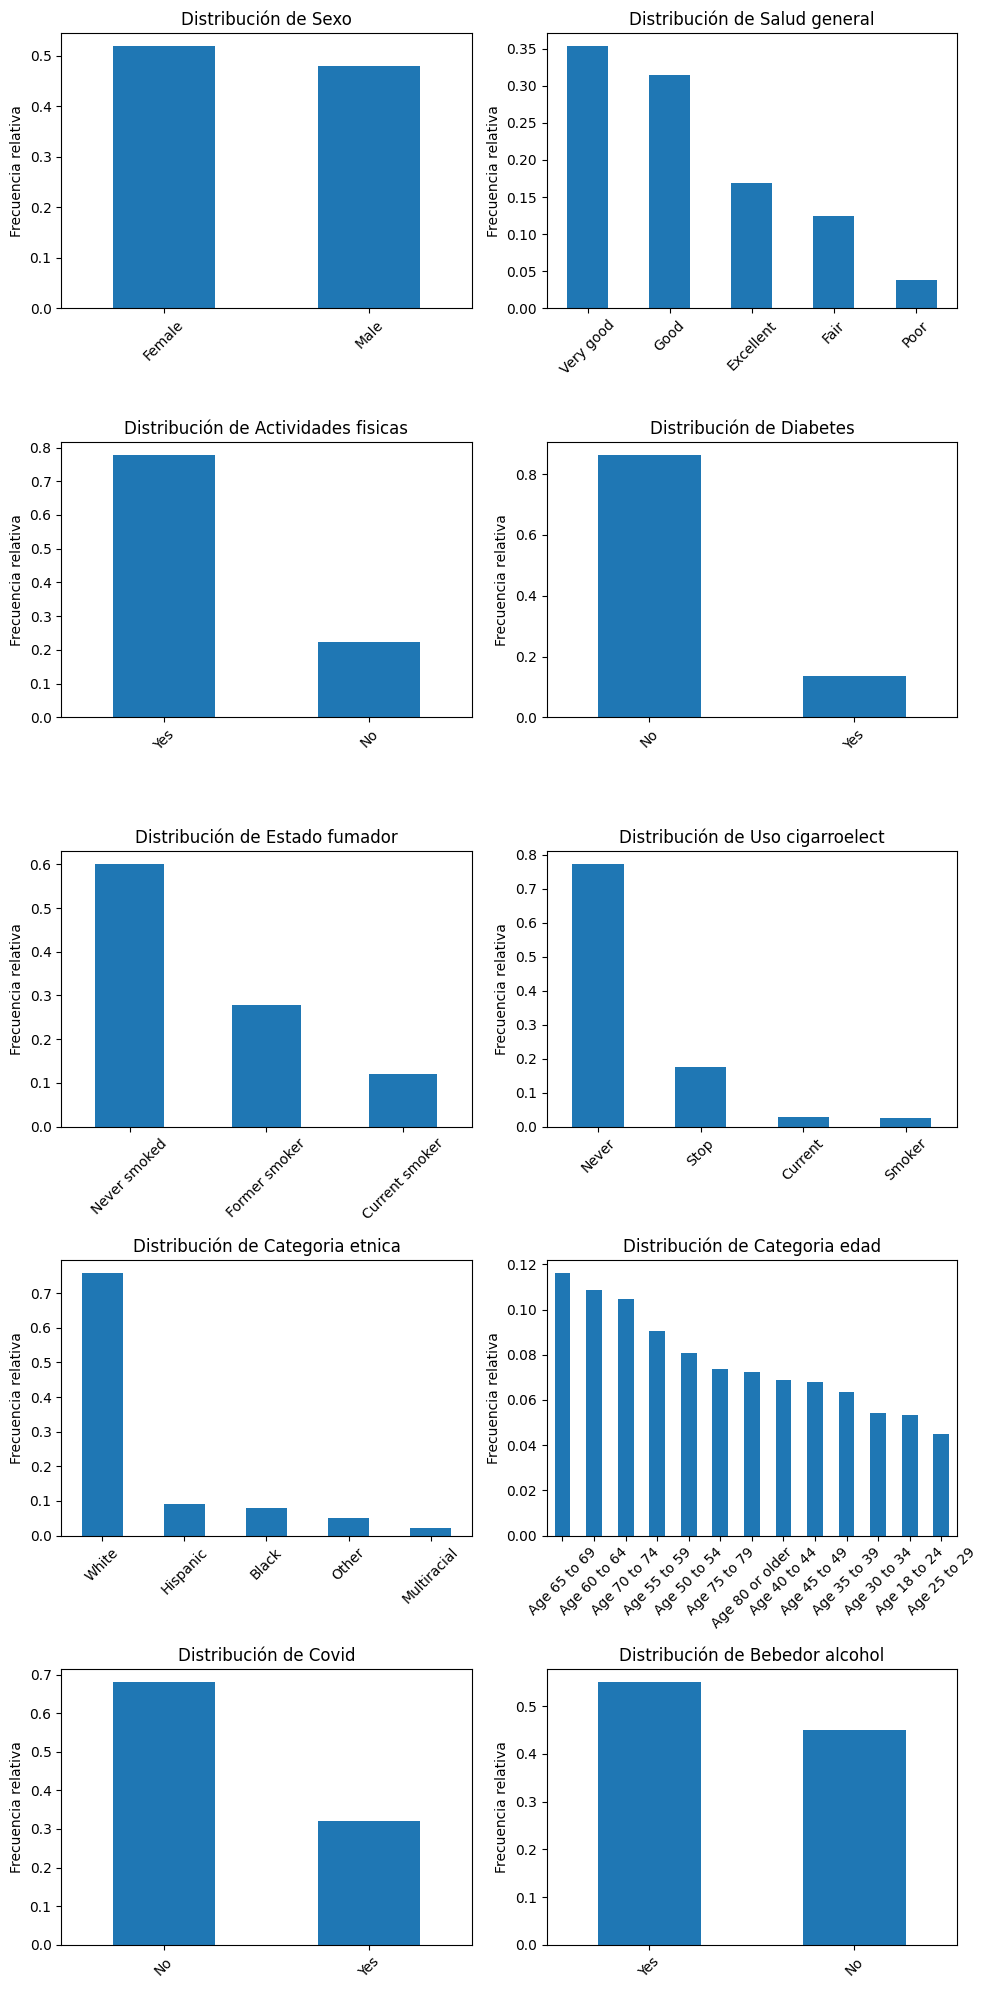

In [25]:

vars = [
    'sexo', 'salud_general', 'actividades_fisicas', 'diabetes',
    'estado_fumador', 'uso_cigarroelect', 'categoria_etnica',
    'categoria_edad', 'covid', 'bebedor_alcohol'
]

# Parámetros de la cuadrícula
per_row = 2
n = len(vars)
rows = math.ceil(n / per_row)

# Crear figura y ejes
fig, axes = plt.subplots(rows, per_row, figsize=(5*per_row, 4*rows), squeeze=False)

# Loop para generar cada gráfico
for ax, var in zip(axes.flat, vars):
    df[var].value_counts(normalize=True) \
           .plot(kind='bar', ax=ax)
    ax.set_title(f"Distribución de {var.replace('_', ' ').capitalize()}")
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia relativa')
    ax.tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos si los hay
for ax in axes.flat[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


A continuación se describen las principales observaciones obtenidas de las distribuciones gráficas de las variables categóricas.



**Distribución de ``sexo``**

- La muestra está equilibrada entre hombres y mujeres, con una ligera mayoría de mujeres (~52%). Esto es positivo porque evita un sesgo de género fuerte en el análisis.  



**Distribución de ``salud_general``** 

- La mayoría de los encuestados perciben su salud como **“Muy buena”** o **“Buena”**. Solo un porcentaje pequeño se ubica en **“Mala”** o **“Pobre”**, lo cual refleja que la población encuestada en general se autopercibe con buen estado de salud.  



**Distribución de ``actividades_fisicas``**
- Cerca del **80%** de las personas realizan actividad física de manera regular, mientras que alrededor del **20%** no lo hace. Esto indica que la muestra tiene un sesgo hacia estilos de vida activos.  



**Distribución de ``diabetes``**

- La mayoría (~85%) **no ha sido diagnosticada con diabetes**, frente a un **15%** que sí. Este dato es clave porque nos permite usar **diabetes** como variable objetivo para análisis predictivos de riesgo.  



**Distribución de ``estado_fumador``**

- La mayoría (~60%) **nunca ha fumado**, seguido de un **27% exfumadores** y un **13% fumadores actuales**. Esto sugiere que existe una fracción considerable de la población con historial de tabaquismo.  



**Distribución de ``uso_cigarroelect``**

- La mayoría (~75%) **nunca ha usado cigarrillos electrónicos**, mientras que alrededor del **17% lo dejó de usar** y solo un porcentaje menor los usa actualmente. Esto refleja que el cigarrillo electrónico aún no es tan prevalente como el tabaco tradicional.  



**Distribución de ``categoria_etnica``**

- Predomina la población **blanca (~73%)**, seguida por **hispanos, afroamericanos, multirraciales y otros grupos** en menor proporción. Esta composición puede generar cierto sesgo demográfico en los análisis.  



**Distribución de ``categoria_edad``**

- Se observa una representación amplia de grupos etarios, con ligera mayor frecuencia en los **grupos de edad avanzada (mayores de 55 años)**. Esto es consistente con encuestas de salud que suelen tener mayor participación de adultos y adultos mayores.  



**Distribución de ``covid``**

- La mayoría (~68%) **no reporta haber tenido COVID**, mientras que un **32% sí**. Esto refleja la alta incidencia de la enfermedad en la población, aunque la mayoría de la muestra no la ha padecido.  



**Distribución de ``bebedor_alcohol``**

- Más de la mitad (~55%) reporta haber **consumido alcohol en el último mes**, mientras que ~45% no. Esto muestra una distribución relativamente equilibrada entre consumidores y no consumidores.  


## **10. Correlación entre variables numéricas**

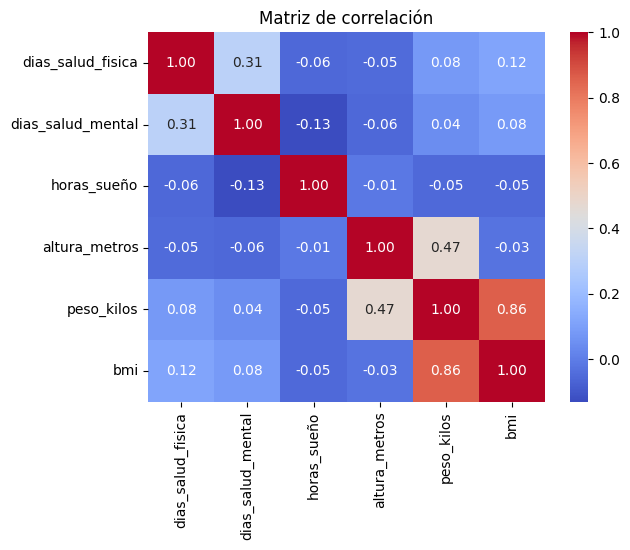

In [26]:
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

La matriz de correlación muestra la relación lineal entre variables numéricas del conjunto de datos. Los valores van de **-1 a 1**, donde:

- **1** indica una correlación positiva perfecta.
- **0** indica ausencia de correlación lineal.
- **-1** indica una correlación negativa perfecta.

### **Principales observaciones**:

- **`peso_kilos` y `bmi`**:  
  - Fuerte correlación positiva (**0.86**), lo esperado ya que el índice de masa corporal (IMC) depende directamente del peso.

- **`altura_metros` y `peso_kilos`**:  
  - Correlación moderada (**0.47**), lo cual indica que las personas más altas tienden a pesar más, aunque no linealmente.

- **`dias_salud_fisica` y `dias_salud_mental`**:  
  - Correlación positiva moderada (**0.31**), lo cual sugiere que quienes reportan mala salud física también tienden a reportar malestar mental.

- **`horas_sueño`**:  
  - Muestra **baja o nula correlación** con las demás variables, indicando que el número de horas dormidas no está linealmente relacionado con salud física, mental o medidas corporales.

- **`bmi` y `dias_salud_fisica`**:  
  - Correlación baja pero positiva (**0.12**), lo que podría sugerir que valores más altos de IMC están ligeramente asociados a más días de mala salud física.

## **11. Analisis bivariado**

### **11.1 Distribución de Diabetes según sexo**

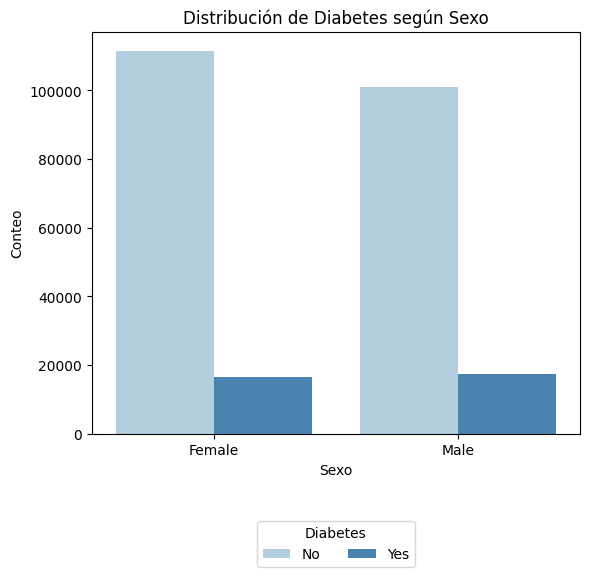

In [27]:
plt.figure(figsize=(6, 6))
sns.countplot(x='sexo', hue='diabetes', data=df, palette="Blues")
plt.title('Distribución de Diabetes según Sexo')
plt.xlabel('Sexo')
plt.ylabel('Conteo')
plt.legend(title='Diabetes',
           loc='upper center',
           bbox_to_anchor=(0.5, -0.20),
           ncol=2)
plt.tight_layout()
plt.show()

El gráfico muestra que la mayoría de los encuestados, tanto hombres como mujeres, **no presentan diabetes**. Sin embargo, se observa una **proporción ligeramente mayor de hombres con diagnóstico de diabetes** en comparación con las mujeres. Además, solo las mujeres reportan casos de diabetes **durante el embarazo**, como era de esperarse. También se identifican casos de **prediabetes o diabetes limítrofe** en ambos sexos, aunque en menor proporción.


### **11.2. Relación entre BMI y días de mala salud física en diabéticos**

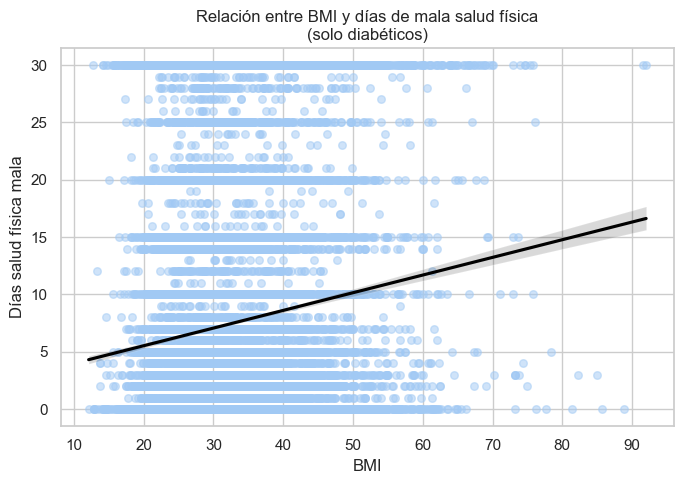

In [28]:
df_diab = df[df['diabetes']=='Yes'].copy()
sns.set(style='whitegrid', palette='pastel')
plt.figure(figsize=(7,5))
sns.regplot(
    x='bmi',
    y='dias_salud_fisica',
    data=df_diab,
    scatter_kws={'alpha':0.5, 's':30},
    line_kws={'color':'black'},
)
plt.title('Relación entre BMI y días de mala salud física\n(solo diabéticos)')
plt.xlabel('BMI')
plt.ylabel('Días salud física mala')
plt.tight_layout()
plt.show()

El gráfico muestra una **relación positiva** entre el índice de masa corporal (BMI) y los **días de mala salud física** en personas con diabetes. A medida que el BMI aumenta, también tiende a aumentar el número de días reportados con malestar físico. Aunque la dispersión es alta, la **tendencia general** sugiere que un mayor BMI podría estar asociado con una peor condición física en personas diabéticas.


### **11.3. Días de mala salud Mental por edad en Diabéticos**

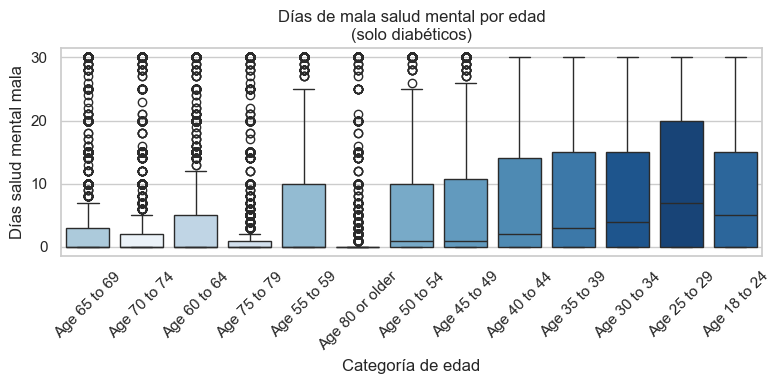

In [29]:
plt.figure(figsize=(8,4))
order_edad = df_diab['categoria_edad'].value_counts().index
sns.boxplot(
    x='categoria_edad',
    y='dias_salud_mental',
    data=df_diab,
    hue='categoria_edad',
    order=order_edad,
    palette="Blues"
)
plt.title('Días de mala salud mental por edad\n(solo diabéticos)')
plt.xlabel('Categoría de edad')
plt.ylabel('Días salud mental mala')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El gráfico muestra la distribución de **días de mala salud mental** entre personas con diabetes, segmentadas por categoría de edad. Se observa una **tendencia clara**: los grupos de edad más jóvenes (especialmente entre **18 y 34 años**) reportan **más días de malestar mental** en promedio, mientras que los adultos mayores tienden a reportar **menos días de afectación**. Esta diferencia sugiere una posible **vulnerabilidad emocional o psicológica mayor en personas jóvenes con diabetes**, en comparación con los grupos mayores.


### **11.4. Top 10 Estados en Número de casos de Diabetes**

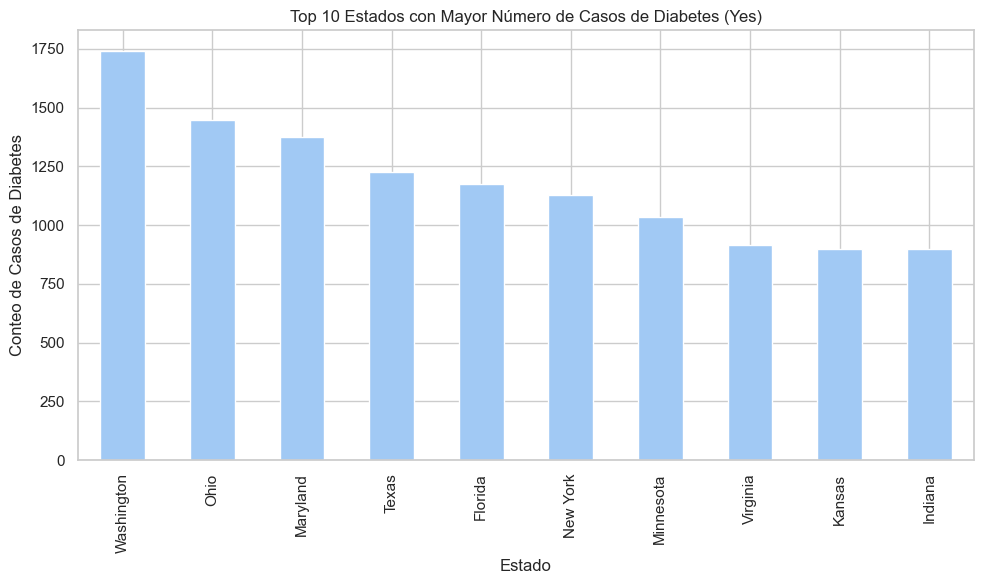

In [30]:
top10_estados = df[df['diabetes'] == 'Yes']['estado'].value_counts().head(10)

# 3. Graficar
plt.figure(figsize=(10, 6))
top10_estados.plot(kind='bar')
plt.title('Top 10 Estados con Mayor Número de Casos de Diabetes (Yes)')
plt.xlabel('Estado')
plt.ylabel('Conteo de Casos de Diabetes')
plt.tight_layout()
plt.show()

El gráfico presenta los **10 estados con mayor número de casos de diabetes diagnosticada** (respuesta "Yes"). **Washington** encabeza la lista con la mayor cantidad de personas con diabetes, seguido por **Ohio** y **Maryland**. Estos resultados permiten identificar regiones con una mayor carga de esta enfermedad, lo cual podría estar relacionado con factores sociodemográficos, acceso a servicios de salud o estilos de vida particulares de cada estado.


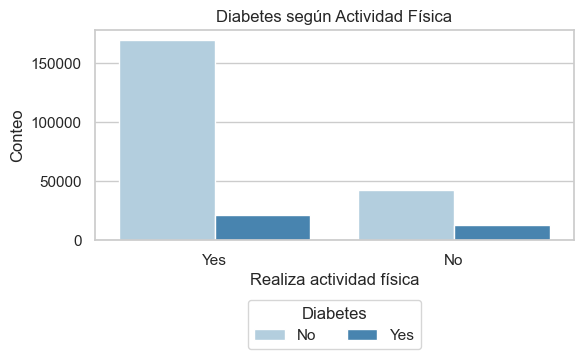

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(x='actividades_fisicas', hue='diabetes', data=df,palette="Blues")
plt.title('Diabetes según Actividad Física')
plt.xlabel('Realiza actividad física')
plt.ylabel('Conteo')
plt.legend(
    title='Diabetes',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2
)
plt.tight_layout()
plt.show()

El gráfico muestra la relación entre la actividad física y la presencia de diabetes. Se observa que la **mayoría de las personas que realizan actividad física no tienen diabetes**. Sin embargo, también hay casos de diabetes entre quienes sí realizan ejercicio, aunque en menor proporción que entre quienes no lo hacen. En el grupo que **no realiza actividad física**, la proporción de personas con diabetes es **visiblemente mayor**, lo que sugiere una posible **asociación negativa entre la inactividad física y el diagnóstico de diabetes**.


## **Conclusiones preliminares del análisis exploratorio**  
El análisis muestra que la prevalencia de diabetes está relacionada con factores de estilo de vida (actividad física, horas de sueño, salud percibida) y con la presencia de enfermedades crónicas (artritis, enfermedad renal, EPOC).  
No se encontraron problemas de valores faltantes, pero sí se observan desigualdades entre grupos poblacionales.  

Como siguiente paso, se recomienda aplicar modelos de Machine Learning para evaluar el poder predictivo de estas variables y así identificar los factores más determinantes en el diagnóstico de diabetes.


Se guarda dataset limpio.

In [32]:
df['diabetes'] = df['diabetes'].apply(lambda x: 1 if x == 'Yes' else 0)

In [33]:
df.to_csv("df_limpio.csv", index=False)